# Logistic Regression — Heart Disease Prediction

This notebook builds a logistic regression classifier for the **UCI Cleveland Heart Disease** dataset.

Each row represents a patient, and the target is whether the patient has heart disease.

## Goals

- Walk through a complete classification workflow:
  - Load the data
  - Perform quick exploratory data analysis
  - Split and scale the features
  - Fit a logistic regression model
  - Evaluate model performance

- Evaluate the classifier using:
  - Accuracy
  - Precision and recall
  - Confusion matrix
  - ROC curve and ROC-AUC

- Interpret the learned coefficients to understand which features are most associated with heart disease risk.

## Dataset

- Source: UCI Cleveland Heart Disease dataset
- Original size: 303 patients
- After dropping rows with missing values: 297 patients
- Features: 13 patient-level variables, including:
  - Age
  - Sex
  - Chest pain type
  - Resting blood pressure
  - Cholesterol
  - Maximum heart rate
  - Exercise-induced angina
  - ST depression
  - Number of major vessels
  - Thalassemia test result

## Target

- The original target ranges from `0` to `4`.
- `0` means no heart disease.
- `1` through `4` indicate some level of heart disease severity.
- In this notebook, the target is converted into a binary classification problem:
  - `0` = healthy
  - `1` = disease

In [1]:
import os
import urllib.request

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), "data") if os.path.basename(os.getcwd()) == "notebooks" else "data"

os.makedirs(DATA_DIR, exist_ok=True)

def download_if_needed(url, filename):
    """Download a CSV if it doesn't already exist locally."""
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"Downloading {filename} from {url}")
        urllib.request.urlretrieve(url, path)
    return path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc,
)

sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load the data

In [2]:
path = download_if_needed(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/processed.cleveland.data.csv",
    "heart_disease.csv",
)

cols = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]

df = pd.read_csv(path, header=None, names=cols, na_values="?").dropna()

# Original target: 0=healthy, 1-4=disease severity. Binarize:
df["target"] = (df["target"] > 0).astype(int)

print("Shape:", df.shape)
print("Class balance:", df["target"].value_counts().to_dict())

df.head()

Shape: (297, 14)
Class balance: {0: 160, 1: 137}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Quick EDA

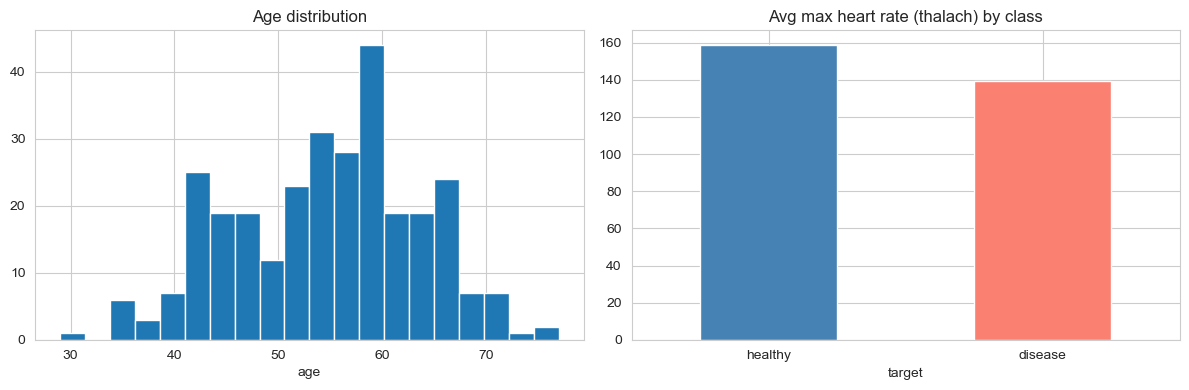

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["age"].hist(bins=20, ax=axes[0])
axes[0].set_title("Age distribution")
axes[0].set_xlabel("age")

df.groupby("target")["thalach"].mean().plot(
    kind="bar", ax=axes[1], color=["steelblue", "salmon"]
)
axes[1].set_title("Avg max heart rate (thalach) by class")
axes[1].set_xticklabels(["healthy", "disease"], rotation=0)

plt.tight_layout()
plt.show()

## 3. Split + scale

In [4]:
X = df.drop(columns="target").values
y = df["target"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()

X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

## 4. Fit logistic regression

In [5]:
clf = LogisticRegression(max_iter=2000, random_state=42).fit(X_tr_s, y_tr)

preds = clf.predict(X_te_s)
probs = clf.predict_proba(X_te_s)[:, 1]

print(f"Accuracy: {accuracy_score(y_te, preds):.4f}\n")
print(classification_report(y_te, preds, target_names=["healthy", "disease"]))

Accuracy: 0.8533

              precision    recall  f1-score   support

     healthy       0.85      0.88      0.86        40
     disease       0.85      0.83      0.84        35

    accuracy                           0.85        75
   macro avg       0.85      0.85      0.85        75
weighted avg       0.85      0.85      0.85        75



## 5. Confusion matrix

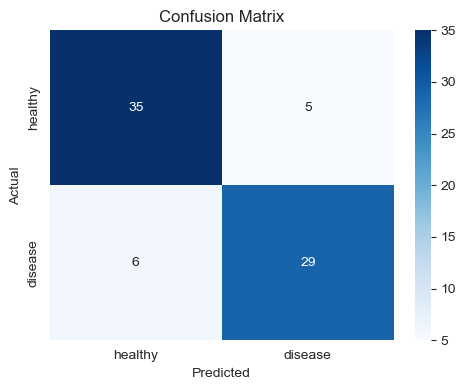

In [6]:
cm = confusion_matrix(y_te, preds)

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "disease"],
    yticklabels=["healthy", "disease"],
    ax=ax,
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

## 6. ROC curve

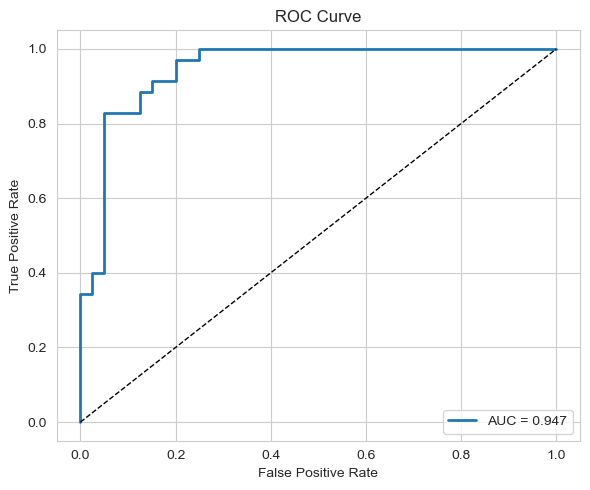

In [7]:
fpr, tpr, _ = roc_curve(y_te, probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Coefficient interpretation

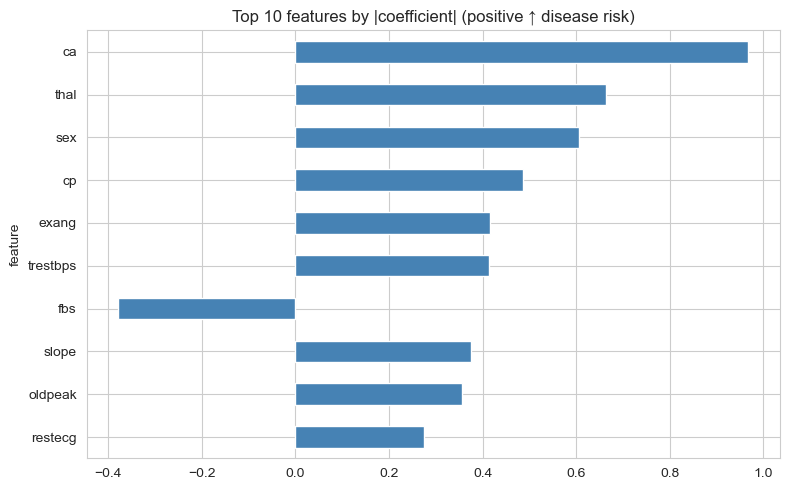

,feature,coef,abs_coef
11,ca,0.968,0.968
12,thal,0.664,0.664
1,sex,0.606,0.606
2,cp,0.485,0.485
8,exang,0.415,0.415
3,trestbps,0.413,0.413
5,fbs,-0.379,0.379
10,slope,0.375,0.375
9,oldpeak,0.356,0.356
6,restecg,0.276,0.276


In [8]:
coef_df = pd.DataFrame(
    {
        "feature": df.drop(columns="target").columns,
        "coef": clf.coef_[0],
    }
).assign(abs_coef=lambda d: d.coef.abs()).sort_values("abs_coef", ascending=False)

coef_df.head(10).plot.barh(
    x="feature",
    y="coef",
    figsize=(8, 5),
    legend=False,
    color="steelblue",
)

plt.gca().invert_yaxis()
plt.title("Top 10 features by |coefficient| (positive ↑ disease risk)")

plt.tight_layout()
plt.show()

coef_df.round(3)


## Takeaways

- Logistic regression reaches about 85% accuracy with AUC ≈ 0.947 on this dataset, which is strong performance for a simple linear classifier.
- The strongest features by absolute coefficient are `ca`, `thal`, and `sex`, followed by `cp`.
- Higher max heart rate, `thalach`, appears protective because its coefficient is negative.
- Feature scaling matters because logistic regression's default L2 regularizer is sensitive to feature scale.